# Required Libraries

In [31]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import ttest_ind
import numpy as np
from scipy.stats import f_oneway
from statsmodels.stats.multicomp import pairwise_tukeyhsd


In [32]:
df = pd.read_csv("Scores.csv", header=None)

df = df[0].str.split(";", expand=True)

df = df.replace('"', '', regex=True)

df.columns = [
    "index",
    "student_id",
    "gender",
    "parental.level.of.education",
    "subject",
    "score"
]

df["score"] = pd.to_numeric(df["score"])

df.head()

,index,student_id,gender,parental.level.of.education,subject,score
0,student_id,gender,parental.level.of.education,subject,score,NaN
1,1,id_001,female,high school,math,23.0
2,2,id_001,female,high school,language,40.0
3,3,id_002,female,high school,math,68.0
4,4,id_002,female,high school,language,80.0


In [33]:
df.drop(index=0,inplace=True)
df.reset_index(drop=True,inplace=True)

In [34]:
df.head()

,index,student_id,gender,parental.level.of.education,subject,score
0,1,id_001,female,high school,math,23.0
1,2,id_001,female,high school,language,40.0
2,3,id_002,female,high school,math,68.0
3,4,id_002,female,high school,language,80.0
4,5,id_003,male,high school,math,82.0


In [35]:
df_clenead=df.copy()
df_clenead = df_clenead.drop(columns=["index"])
df_clenead.head()

,student_id,gender,parental.level.of.education,subject,score
0,id_001,female,high school,math,23.0
1,id_001,female,high school,language,40.0
2,id_002,female,high school,math,68.0
3,id_002,female,high school,language,80.0
4,id_003,male,high school,math,82.0


In [36]:
print(df_clenead.isna().sum())

student_id                     0
gender                         0
parental.level.of.education    0
subject                        0
score                          0
dtype: int64


In [37]:
print(df.dtypes)

index                           object
student_id                      object
gender                          object
parental.level.of.education     object
subject                         object
score                          float64
dtype: object


In [38]:
df.to_csv("clean_scores.csv",index=False)

In [39]:
df_wide = df_clenead.pivot_table(
    index=["student_id", "gender", "parental.level.of.education"],
    columns="subject",
    values="score"
).reset_index()

df_wide.head()

subject,student_id,gender,parental.level.of.education,language,math
0,id_001,female,high school,40.0,23.0
1,id_002,female,high school,80.0,68.0
2,id_003,male,high school,81.0,82.0
3,id_004,female,high school,60.0,58.0
4,id_005,female,high school,69.0,60.0


# Overall Descriptive Statics

In [40]:
df_wide.describe()

subject,language,math
count,486.000000,486.000000
mean,68.746914,66.380658
std,14.454184,15.054580
min,19.000000,23.000000
25%,58.000000,56.000000
50%,70.000000,66.000000
75%,78.000000,77.750000
max,100.000000,100.000000


# Descriptive Statics by Gender

In [41]:
df_wide.groupby("gender")[["math"]].describe()

subject   math                                                     
         count       mean        std   min   25%   50%   75%    max
gender                                                             
female   245.0  63.857143  15.261921  23.0  54.0  64.0  74.0  100.0
male     241.0  68.946058  14.425137  30.0  58.0  70.0  80.0  100.0

In [42]:
df_wide.groupby("gender")[["language"]].describe()

subject language                                                     
           count       mean        std   min   25%   50%   75%    max
gender                                                               
female     245.0  72.746939  14.017891  29.0  64.0  73.0  82.0  100.0
male       241.0  64.680498  13.765355  19.0  54.0  65.0  75.0  100.0

In [43]:
df_wide.groupby("parental.level.of.education")[["math"]].describe()

subject                       math                                           \
                             count       mean        std   min    25%   50%   
parental.level.of.education                                                   
associate's degree           177.0  67.813559  15.244382  26.0  57.00  66.0   
bachelor's degree             94.0  68.436170  15.048708  29.0  61.00  67.0   
high school                  156.0  62.243590  14.036989  23.0  53.75  63.0   
master's degree               59.0  69.745763  15.153915  40.0  55.50  73.0   

subject                                    
                               75%    max  
parental.level.of.education                
associate's degree           81.00  100.0  
bachelor's degree            77.75  100.0  
high school                  71.00   94.0  
master's degree              81.00   95.0

In [44]:
df_wide.groupby("parental.level.of.education")[["language"]].describe()

subject                     language                                          \
                               count       mean        std   min   25%   50%   
parental.level.of.education                                                    
associate's degree             177.0  69.779661  14.233525  34.0  59.0  72.0   
bachelor's degree               94.0  71.787234  14.285772  40.0  63.0  73.0   
high school                    156.0  63.282051  13.398505  19.0  53.0  65.0   
master's degree                 59.0  75.254237  13.551426  44.0  66.0  76.0   

subject                                   
                              75%    max  
parental.level.of.education               
associate's degree           79.0  100.0  
bachelor's degree            80.0  100.0  
high school                  73.0   99.0  
master's degree              85.5  100.0

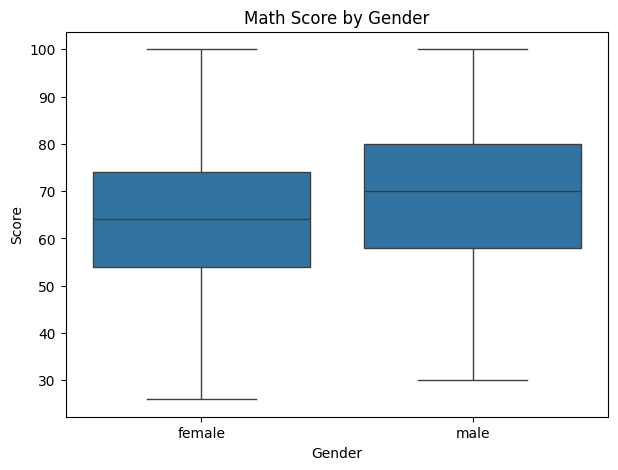

In [45]:
plt.figure(figsize=(7,5))

sns.boxplot(
    x="gender",
    y="math",
    data=df_wide,
    showfliers=False
)

plt.title("Math Score by Gender")
plt.xlabel("Gender")
plt.ylabel("Score")

plt.show()

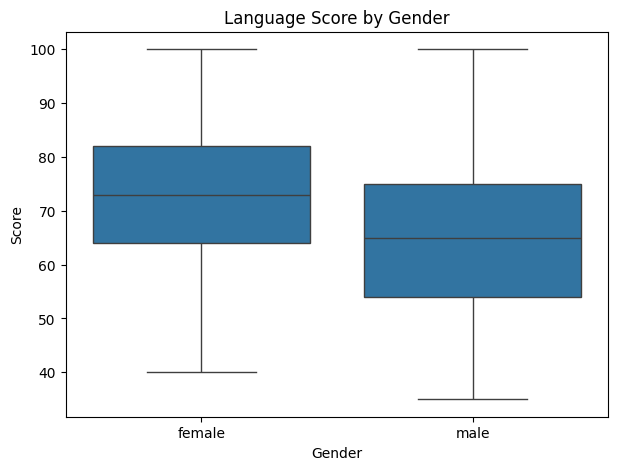

In [46]:
plt.figure(figsize=(7,5))

sns.boxplot(
    x="gender",
    y="language",
    data=df_wide,
    showfliers=False
)

plt.title("Language Score by Gender")
plt.xlabel("Gender")
plt.ylabel("Score")

plt.show()

# Independent Samples t-test

# T-Test Math-Gender

In [47]:
df_wide.groupby("gender")[["math", "language"]].mean()

subject,math,language
gender,,
female,63.857143,72.746939
male,68.946058,64.680498


In [48]:
from scipy.stats import ttest_ind

male_math = df_wide[df_wide["gender"] == "male"]["math"]
female_math = df_wide[df_wide["gender"] == "female"]["math"]

t_stat, p_value = ttest_ind(male_math, female_math)

print("Math T-test p-value:", p_value)

Math T-test p-value: 0.00017884036695534617


In [49]:
male_math = df_wide[df_wide["gender"] == "male"]["math"]
female_math = df_wide[df_wide["gender"] == "female"]["math"]

t_stat, p_value = ttest_ind(male_math, female_math)

mean_male = np.mean(male_math)
mean_female = np.mean(female_math)
difference = mean_male - mean_female

n1 = len(male_math)
n2 = len(female_math)
df = n1 + n2 - 2

alpha = 0.05
decision = "Significant" if p_value < alpha else "Not Significant"

print("t-statistic:", t_stat)
print("Difference Male - Female:", difference)
print("df:", df)
print("p-value:", p_value)
print("Decision:", decision)

t-statistic: 3.776486726932324
Difference Male - Female: 5.08891523414345
df: 484
p-value: 0.00017884036695534617
Decision: Significant


In [50]:
groups = [
    group["math"].values
    for name, group in df_wide.groupby("parental.level.of.education")
]

f_stat, p_value = f_oneway(*groups)

k = len(groups)

N = sum(len(g) for g in groups)

df_between = k - 1
df_within = N - k

alpha = 0.05
result = "Significant" if p_value < alpha else "Not Significant"

print("F-statistic:", f_stat)
print("p-value:", p_value)
print("df between:", df_between)
print("df within:", df_within)
print("Result:", result)

F-statistic: 6.222926244479986
p-value: 0.0003750888011046905
df between: 3
df within: 482
Result: Significant


# T-Test Language-Gender

In [51]:
male_lang = df_wide[df_wide["gender"] == "male"]["language"]
female_lang = df_wide[df_wide["gender"] == "female"]["language"]

t_stat, p_value = ttest_ind(male_lang, female_lang)

print("Language T-test p-value:", p_value)

Language T-test p-value: 3.6839324194707487e-10


In [52]:
male_math = df_wide[df_wide["gender"] == "male"]["language"]
female_math = df_wide[df_wide["gender"] == "female"]["language"]

t_stat, p_value = ttest_ind(male_math, female_math)

mean_male = np.mean(male_math)
mean_female = np.mean(female_math)
difference = mean_male - mean_female

n1 = len(male_math)
n2 = len(female_math)
df = n1 + n2 - 2

alpha = 0.05
decision = "Significant" if p_value < alpha else "Not Significant"

print("t-statistic:", t_stat)
print("Difference Male - Female:", difference)
print("df:", df)
print("p-value:", p_value)
print("Decision:", decision)

t-statistic: -6.399585357241521
Difference Male - Female: -8.066440850199001
df: 484
p-value: 3.6839324194707487e-10
Decision: Significant


# Question 2 - Descriptive Statics by Parental Education

In [53]:
df_wide.groupby("parental.level.of.education")[["language"]].describe()

subject                     language                                          \
                               count       mean        std   min   25%   50%   
parental.level.of.education                                                    
associate's degree             177.0  69.779661  14.233525  34.0  59.0  72.0   
bachelor's degree               94.0  71.787234  14.285772  40.0  63.0  73.0   
high school                    156.0  63.282051  13.398505  19.0  53.0  65.0   
master's degree                 59.0  75.254237  13.551426  44.0  66.0  76.0   

subject                                   
                              75%    max  
parental.level.of.education               
associate's degree           79.0  100.0  
bachelor's degree            80.0  100.0  
high school                  73.0   99.0  
master's degree              85.5  100.0

In [54]:
df_wide.groupby("parental.level.of.education")[["math"]].describe()

subject                       math                                           \
                             count       mean        std   min    25%   50%   
parental.level.of.education                                                   
associate's degree           177.0  67.813559  15.244382  26.0  57.00  66.0   
bachelor's degree             94.0  68.436170  15.048708  29.0  61.00  67.0   
high school                  156.0  62.243590  14.036989  23.0  53.75  63.0   
master's degree               59.0  69.745763  15.153915  40.0  55.50  73.0   

subject                                    
                               75%    max  
parental.level.of.education                
associate's degree           81.00  100.0  
bachelor's degree            77.75  100.0  
high school                  71.00   94.0  
master's degree              81.00   95.0

In [55]:

groups = [
    group["math"].values
    for name, group in df_wide.groupby("parental.level.of.education")
]

f_stat, p_value = f_oneway(*groups)

k = len(groups)

N = sum(len(g) for g in groups)

df_between = k - 1
df_within = N - k

alpha = 0.05
decision = "Significant" if p_value < alpha else "Not Significant"

print("F-statistic:", f_stat)
print("df-between:", df_between)
print("df-within:", df_within)
print("p-value:", p_value)
print("Decision:", decision)

F-statistic: 6.222926244479986
df-between: 3
df-within: 482
p-value: 0.0003750888011046905
Decision: Significant


In [56]:
groups = [
    group["language"].values
    for name, group in df_wide.groupby("parental.level.of.education")
]

f_stat, p_value = f_oneway(*groups)

k = len(groups)

N = sum(len(g) for g in groups)

df_between = k - 1
df_within = N - k

alpha = 0.05
decision = "Significant" if p_value < alpha else "Not Significant"

print("F-statistic:", f_stat)
print("df-between:", df_between)
print("df-within:", df_within)
print("p-value:", p_value)
print("Decision:", decision)

F-statistic: 14.174911024314852
df-between: 3
df-within: 482
p-value: 7.230183560272925e-09
Decision: Significant


# Tukey’s Honestly Significant Difference (HSD)

In [57]:
tukey = pairwise_tukeyhsd(
    endog=df_wide["math"],
    groups=df_wide["parental.level.of.education"],
    alpha=0.05
)

print(tukey)

            Multiple Comparison of Means - Tukey HSD, FWER=0.05             
      group1             group2      meandiff p-adj   lower    upper  reject
----------------------------------------------------------------------------
associate's degree bachelor's degree   0.6226 0.9877  -4.2525  5.4977  False
associate's degree       high school    -5.57 0.0037  -9.7649 -1.3751   True
associate's degree   master's degree   1.9322 0.8217  -3.8102  7.6746  False
 bachelor's degree       high school  -6.1926 0.0079 -11.1802  -1.205   True
 bachelor's degree   master's degree   1.3096 0.9512   -5.035  7.6542  False
       high school   master's degree   7.5022 0.0055   1.6639 13.3404   True
----------------------------------------------------------------------------


In [58]:
tukey = pairwise_tukeyhsd(
    endog=df_wide["language"],
    groups=df_wide["parental.level.of.education"],
    alpha=0.05
)

print(tukey)

            Multiple Comparison of Means - Tukey HSD, FWER=0.05             
      group1             group2      meandiff p-adj   lower    upper  reject
----------------------------------------------------------------------------
associate's degree bachelor's degree   2.0076 0.6701  -2.5654  6.5806  False
associate's degree       high school  -6.4976 0.0001 -10.4326 -2.5627   True
associate's degree   master's degree   5.4746 0.0447    0.088 10.8611   True
 bachelor's degree       high school  -8.5052    0.0 -13.1837 -3.8266   True
 bachelor's degree   master's degree    3.467 0.4372  -2.4844  9.4185  False
       high school   master's degree  11.9722    0.0   6.4958 17.4486   True
----------------------------------------------------------------------------


# Graphs

c:\Users\roozb\AppData\Local\Programs\Python\Python313\Lib\site-packages\seaborn\axisgrid.py:854: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  func(*plot_args, **plot_kwargs)
c:\Users\roozb\AppData\Local\Programs\Python\Python313\Lib\site-packages\seaborn\axisgrid.py:854: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  func(*plot_args, **plot_kwargs)


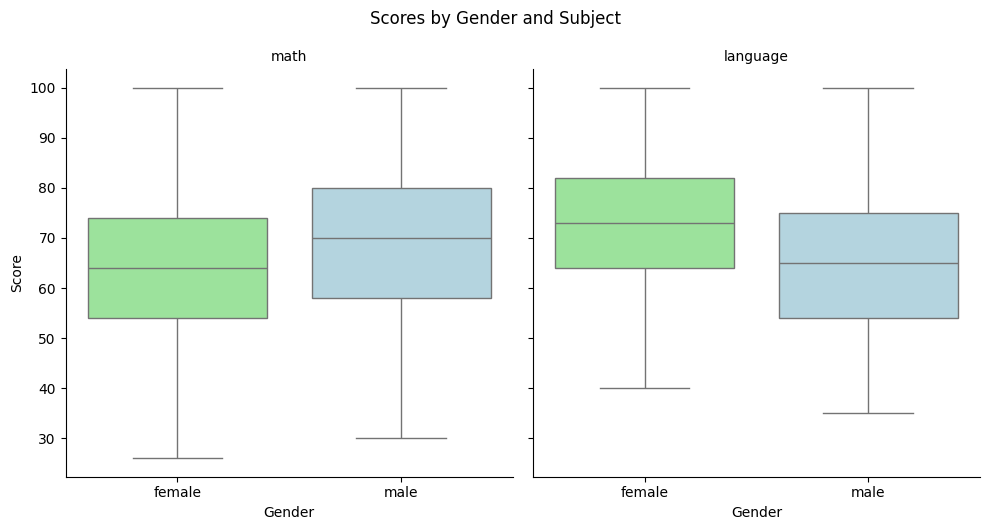

In [59]:
import seaborn as sns
import matplotlib.pyplot as plt

g = sns.FacetGrid(
    df_clenead,
    col="subject",
    height=5,
    aspect=1
)

g.map_dataframe(
    sns.boxplot,
    x="gender",
    y="score",
    showfliers=False,
    palette=["lightgreen", "lightblue"]
)

g.set_titles("{col_name}")

g.figure.suptitle("Scores by Gender and Subject", y=1.05)

g.set_axis_labels("Gender", "Score")

plt.show()

C:\Users\roozb\AppData\Local\Temp\ipykernel_32820\21964099.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


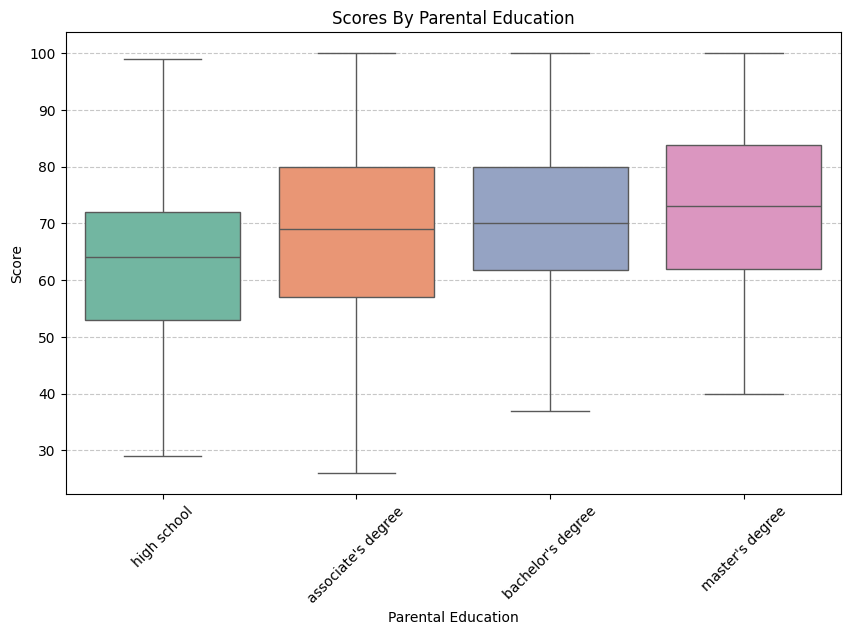

In [60]:
plt.figure(figsize=(10,6))

sns.boxplot(
    x="parental.level.of.education",
    y="score",
    data=df_clenead,
    palette="Set2",
    showfliers=False
)

plt.title("Scores By Parental Education")
plt.ylabel("Score")
plt.xlabel("Parental Education")

plt.xticks(rotation=45)
plt.grid(axis='y', linestyle='--', alpha=0.7)

plt.show()